In [1]:
# Install unzip
# !apt-get install unzip

# Unzip the zip file
# !unzip "./balanced_photos_folder.zip"

In [2]:
# Install GLIDE
# !pip install git+https://github.com/openai/glide-text2im

In [3]:
# !pip install tqdm numpy scipy scikit-learn torch torchvision

In [4]:
# Import the necessary libraries
import os
import time
import torch
import torch.nn as nn
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from IPython.display import display
import torch.optim as optim

from torchvision.models.inception import inception_v3
from scipy.linalg import sqrtm
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision.utils import make_grid

import warnings
warnings.filterwarnings('ignore')

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
# Import GLIDE
from glide_text2im.download import load_checkpoint
from glide_text2im.model_creation import (
    create_model_and_diffusion,
    model_and_diffusion_defaults,
    model_and_diffusion_defaults_upsampler
)

In [6]:
# Training Configuration
BATCH_SIZE = 4
LEARNING_RATE = 1e-5
NUM_EPOCHS = 10
SAVE_INTERVAL = 2
MAX_SAMPLES_PER_CLASS = 200

In [7]:
IMAGE_DIR = "./balanced_photos_folder"
image_size = 64  # GLIDE base model input

# Load metadata
import json

data = []
with open("./photos.json", 'r') as f:
    for line in f:
        data.append(json.loads(line))
df = pd.DataFrame(data)

TARGET_LABELS = df["label"].unique().tolist()
print(f"Labels found: {TARGET_LABELS}")

Labels found: ['inside', 'outside', 'drink', 'food', 'menu']


In [8]:
# Create more descriptive captions from labels
def create_caption(label):
    caption_templates = {
        'food': 'a delicious plate of food at a restaurant',
        'menu': 'a restaurant menu showing food items',
        'inside': 'interior view of a restaurant or cafe',
        'outside': 'exterior view of a restaurant building',
        'drink': 'a refreshing drink or beverage'
    }
    return caption_templates.get(label.lower(), f"a photo of {label}")

In [9]:
# Add descriptive captions to dataframe
df['caption'] = df['label'].apply(create_caption)

In [10]:
# Image transform for training
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(p=0.5),  # Data augmentation
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [11]:
# Balanced sampling for training
def balanced_sample(df, labels, max_per_class=None):
    samples = []
    if max_per_class is None:
        # Calculate the minimum number of samples per class from the original dataframe
        min_samples = df['label'].value_counts().min()
        sample_size_per_class = min_samples
        print(f"Balancing based on the smallest class size: {sample_size_per_class}")
    else:
        sample_size_per_class = max_per_class
        print(f"Balancing based on fixed max_per_class: {sample_size_per_class}")


    for label in labels:
        label_data = df[df["label"] == label]
        # Ensure we don't sample more than available data for any class
        sample_size = min(len(label_data), sample_size_per_class)
        samples.append(label_data.sample(sample_size, random_state=42))
    return pd.concat(samples).reset_index(drop=True)

# Get list of available image files
available_images = [f.split('.')[0] for f in os.listdir(IMAGE_DIR) if f.endswith('.jpg')]

# Filter DataFrame to include only available images
df_filtered = df[df['photo_id'].isin(available_images)].copy()
print(f"Filtered down to {len(df_filtered)} entries with available images.")

# Balance based on available images and select a maximum of 200 per class
MAX_SAMPLES_PER_CLASS = 200
df_train = balanced_sample(df_filtered, TARGET_LABELS, max_per_class=MAX_SAMPLES_PER_CLASS)
print(f"Training samples: {len(df_train)}")

Filtered down to 8390 entries with available images.
Balancing based on fixed max_per_class: 200
Training samples: 1000


In [12]:
# Dataset Class for Training
class YelpTrainingDataset(Dataset):
    def __init__(self, df, image_dir, transform):
        self.df = df
        self.image_dir = image_dir
        self.transform = transform

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # Corrected: Use 'photo_id' instead of 'image_id'
        img_path = os.path.join(self.image_dir, f"{row['photo_id']}.jpg")

        try:
            img = Image.open(img_path).convert("RGB")
            img_tensor = self.transform(img)
            caption = row["caption"]
            return img_tensor, caption
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return a dummy image and caption in case of error
            dummy_img = torch.randn(3, self.transform.transforms[0].size[0], self.transform.transforms[0].size[1])
            return self.transform.transforms[-1](dummy_img), "a photo"

    def __len__(self):
        return len(self.df)

In [13]:
# Create training dataset and dataloader
train_dataset = YelpTrainingDataset(df_train, IMAGE_DIR, transform)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

## GLIDE Model Setup

In [14]:
base_opts = model_and_diffusion_defaults()
base_opts.update({
    'use_fp16': False,
    'timestep_respacing': '1000'  # Full timesteps for training
})

model, diffusion = create_model_and_diffusion(**base_opts)
model.train()
model.to(device)

# Load pre-trained weights
model.load_state_dict(load_checkpoint('base', device))
print("Base model loaded successfully!")

# Setup optimizer
trainable_params = []
for name, param in model.named_parameters():
    param.requires_grad = True
    trainable_params.append(param)


optimizer = optim.AdamW(trainable_params, lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print(f"Training {sum(p.numel() for p in trainable_params)} parameters")

Base model loaded successfully!
Training 385030726 parameters


## Training GLIDE

In [15]:
# Training Function
def train_glide(model, diffusion, dataloader, optimizer, scheduler, num_epochs, device):
    model.train()
    training_losses = []

    print("Starting GLIDE fine-tuning...")

    for epoch in range(num_epochs):
        epoch_losses = []
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for batch_idx, (images, captions) in enumerate(pbar):
            images = images.to(device)

            # Tokenize captions
            batch_tokens = []
            batch_masks = []

            for caption in captions:
                tokens = model.tokenizer.encode(caption)
                tokens, mask = model.tokenizer.padded_tokens_and_mask(
                    tokens, base_opts['text_ctx']
                )
                batch_tokens.append(tokens)
                batch_masks.append(mask)

            # Convert to tensors
            tokens_tensor = torch.tensor(batch_tokens, device=device)
            masks_tensor = torch.tensor(batch_masks, dtype=torch.bool, device=device)

            # Sample random timesteps
            t = torch.randint(0, diffusion.num_timesteps, (images.shape[0],), device=device)

            # Add noise to images
            noise = torch.randn_like(images)
            x_t = diffusion.q_sample(images, t, noise=noise)

            # Model forward pass
            model_kwargs = dict(tokens=tokens_tensor, mask=masks_tensor)

            try:
                # Predict noise
                predicted_output = model(x_t, t, **model_kwargs)

                # Extract the predicted noise component (first 3 channels)
                predicted_noise = predicted_output[:, :3, :, :]

                # Compute loss
                loss = nn.functional.mse_loss(predicted_noise, noise)

                # Backward pass
                optimizer.zero_grad()
                loss.backward()

                # Gradient clipping
                torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)

                optimizer.step()

                epoch_losses.append(loss.item())
                pbar.set_postfix({'Loss': f'{loss.item():.4f}'})

            except Exception as e:
                print(f"Error in training step: {e}")
                continue

        # Update learning rate
        scheduler.step()

        # Calculate average loss for epoch
        avg_loss = np.mean(epoch_losses) if epoch_losses else 0.0
        training_losses.append(avg_loss)

        # Print epoch and average loss after 100% completion
        print(f"Epoch {epoch+1}/{num_epochs} - Average Loss: {avg_loss:.4f}")


        # Save checkpoint
        if (epoch + 1) % SAVE_INTERVAL == 0:
            checkpoint_path = f"glide_yelp_epoch_{epoch+1}.pt"
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'epoch': epoch,
                'loss': avg_loss
            }, checkpoint_path)
            print(f"Checkpoint saved: {checkpoint_path}")

    return training_losses

In [16]:
# Fine-tune the model
print("Starting fine-tuning process...")
training_losses = train_glide(model, diffusion, train_dataloader, optimizer, scheduler, NUM_EPOCHS, device)

Starting fine-tuning process...
Starting GLIDE fine-tuning...


Epoch 1/10: 100%|██████████| 250/250 [03:31<00:00,  1.18it/s, Loss=0.0244]


Epoch 1/10 - Average Loss: 0.0433


Epoch 2/10: 100%|██████████| 250/250 [03:28<00:00,  1.20it/s, Loss=0.0255]


Epoch 2/10 - Average Loss: 0.0440
Checkpoint saved: glide_yelp_epoch_2.pt


...

Epoch 8/10 - Average Loss: 0.0447
Checkpoint saved: glide_yelp_epoch_8.pt


Epoch 9/10: 100%|██████████| 250/250 [03:38<00:00,  1.14it/s, Loss=0.0480]


Epoch 9/10 - Average Loss: 0.0435


Epoch 10/10: 100%|██████████| 250/250 [03:28<00:00,  1.20it/s, Loss=0.0388]


Epoch 10/10 - Average Loss: 0.0442
Checkpoint saved: glide_yelp_epoch_10.pt


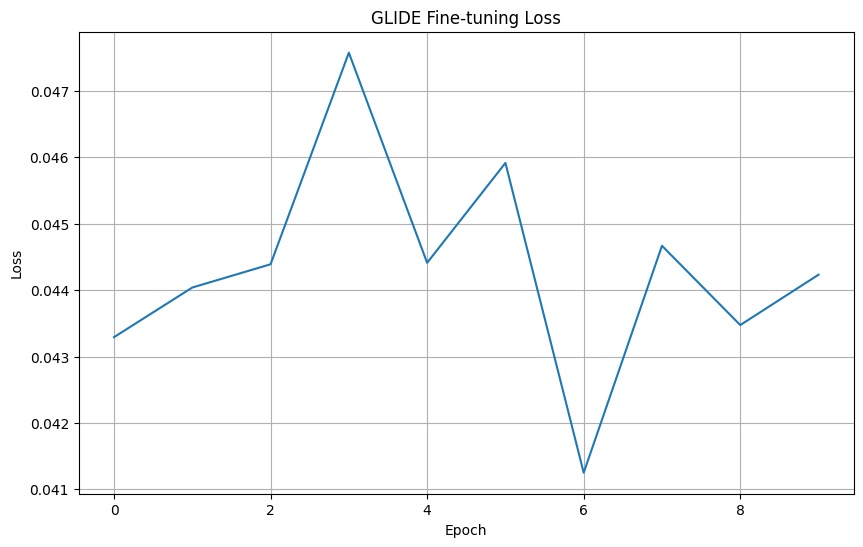

In [17]:
# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(training_losses)
plt.title('GLIDE Fine-tuning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [18]:
# Load upsampler for inference
print("Loading GLIDE upsampler model...")
up_opts = model_and_diffusion_defaults_upsampler()
up_opts.update({
    'use_fp16': False,
    'timestep_respacing': 'fast27'
})
model_up, diffusion_up = create_model_and_diffusion(**up_opts)
model_up.eval()
model_up.to(device)
model_up.load_state_dict(load_checkpoint('upsample', device))

Loading GLIDE upsampler model...


  0%|          | 0.00/1.59G [00:00<?, ?iB/s]

<All keys matched successfully>

## Image Generation Pipeline

In [19]:
def generate_glide_image(prompt, model, diffusion, upsampler, up_diffusion, device, batch_size=1, guidance_scale=3.0):

    model.eval()

    try:
        with torch.no_grad():
            # Tokenize prompt
            tokens = model.tokenizer.encode(prompt)
            tokens, mask = model.tokenizer.padded_tokens_and_mask(tokens, base_opts['text_ctx'])
            uncond_tokens, uncond_mask = model.tokenizer.padded_tokens_and_mask([], base_opts['text_ctx'])

            # Create model kwargs
            model_kwargs = dict(
                tokens=torch.tensor([tokens]*batch_size + [uncond_tokens]*batch_size, device=device),
                mask=torch.tensor([mask]*batch_size + [uncond_mask]*batch_size, dtype=torch.bool, device=device),
            )

            # Define model function for classifier-free guidance
            def model_fn(x_t, ts, **kwargs):
                half = x_t[: len(x_t) // 2]
                combined = torch.cat([half, half], dim=0)
                model_out = model(combined, ts, **kwargs)

                # Handle model output format
                if model_out.shape[1] == 6:  # [noise, variance]
                    eps, rest = model_out[:, :3], model_out[:, 3:]
                else:
                    eps = model_out
                    rest = torch.zeros_like(eps)

                cond_eps, uncond_eps = torch.split(eps, len(eps) // 2, dim=0)
                half_eps = uncond_eps + guidance_scale * (cond_eps - uncond_eps)
                eps = torch.cat([half_eps, half_eps], dim=0)

                if rest.numel() > 0:
                    return torch.cat([eps, rest], dim=1)
                else:
                    return eps

            # Generate base resolution images
            base_samples = diffusion.p_sample_loop(
                model_fn,
                (batch_size*2, 3, base_opts['image_size'], base_opts['image_size']),
                device=device,
                clip_denoised=True,
                model_kwargs=model_kwargs
            )[:batch_size]

            # Upsample the images
            up_tokens = upsampler.tokenizer.encode(prompt)
            up_tokens, up_mask = upsampler.tokenizer.padded_tokens_and_mask(up_tokens, up_opts['text_ctx'])

            up_kwargs = dict(
                low_res=((base_samples + 1)*127.5).round()/127.5 - 1,
                tokens=torch.tensor([up_tokens]*batch_size, device=device),
                mask=torch.tensor([up_mask]*batch_size, dtype=torch.bool, device=device),
            )

            upsampled = diffusion_up.ddim_sample_loop(
                upsampler,
                (batch_size, 3, up_opts['image_size'], up_opts['image_size']),
                noise=torch.randn((batch_size, 3, up_opts['image_size'], up_opts['image_size']), device=device),
                device=device,
                clip_denoised=True,
                model_kwargs=up_kwargs
            )

        return upsampled

    except Exception as e:
        print(f"Error in image generation: {e}")
        return None

## Evaluation Metrics (IS and FID)

In [20]:
# Evaluation Metrics
print("Loading Inception model for evaluation...")
inception_model = inception_v3(pretrained=True, transform_input=False).eval().to(device)

def compute_inception_features(images):
    with torch.no_grad():
        images = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)
        features = inception_model(images)
        if isinstance(features, tuple):
            features = features[0]
        return features

def compute_metrics(generated_images):
    try:
        with torch.no_grad():
            # Inception Score
            resized_images = F.interpolate(generated_images, size=(299, 299), mode='bilinear', align_corners=False)
            preds = inception_model(resized_images)
            if isinstance(preds, tuple):
                preds = preds[0]
            preds = F.softmax(preds, dim=1).cpu().numpy()

            p_y = np.mean(preds, axis=0)
            kl_div = preds * (np.log(preds + 1e-10) - np.log(p_y + 1e-10))
            inception_score = np.exp(np.mean(np.sum(kl_div, axis=1)))

            # Simplified FID
            gen_features = compute_inception_features(generated_images).cpu().numpy()
            mu_gen = np.mean(gen_features, axis=0)
            sigma_gen = np.cov(gen_features, rowvar=False)
            fid_score = np.trace(sigma_gen)

        return inception_score, fid_score

    except Exception as e:
        print(f"Error computing metrics: {e}")
        return 0.0, 0.0

Loading Inception model for evaluation...


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:01<00:00, 86.5MB/s]


## Generate and Display 5 Samples (One per Label)

In [21]:
# Generate 5 samples (one per label) using fine-tuned model
from torchvision.utils import make_grid

def generate_final_samples(model, diffusion, upsampler, upsampler_diffusion, device, labels):
    print("="*60)
    print("GENERATING 5 SAMPLES WITH FINE-TUNED GLIDE")
    print("="*60)

    model.eval()
    images = []
    successful_labels = []
    captions_used = []

    # Use first 5 labels
    labels_to_use = labels[:5] if len(labels) > 5 else labels

    for label in tqdm(labels_to_use, desc="Generating with fine-tuned model"):
        caption = create_caption(label)
        print(f"Generating for label '{label}' with caption: '{caption}'")

        try:
            image = generate_glide_image(
                caption,
                model,
                diffusion,
                upsampler,
                upsampler_diffusion,
                device,
                batch_size=1
            )

            if image is not None:
                images.append(image[0])
                successful_labels.append(label)
                captions_used.append(caption)
                print(f"Successfully generated image for '{label}'")
            else:
                print(f"Failed to generate image for '{label}'")

        except Exception as e:
            print(f"Error generating image for '{label}': {e}")

    if len(images) == 0:
        print("No images were successfully generated!")
        return None, 0.0, 0.0

    # Stack into batch and compute metrics
    generated_batch = torch.stack(images)
    print(f"Generated {len(images)} images successfully")

    # Compute metrics
    print("Computing IS and FID metrics...")
    is_score, fid_score = compute_metrics(generated_batch)

    # Create and display image grid
    denorm = lambda x: torch.clamp(x * 0.5 + 0.5, 0, 1)
    grid_img = make_grid(denorm(generated_batch.cpu()), nrow=len(images), padding=2)

    plt.figure(figsize=(20, 4))
    plt.imshow(grid_img.permute(1, 2, 0).numpy())
    plt.axis('off')
    plt.title(f"Fine-tuned GLIDE Generated Samples\nLabels: {', '.join(successful_labels)}", fontsize=16)
    plt.tight_layout()
    plt.show()

    return grid_img, is_score, fid_score, successful_labels, captions_used

GENERATING 5 SAMPLES WITH FINE-TUNED GLIDE


Generating with fine-tuned model:   0%|          | 0/5 [00:00<?, ?it/s]

Generating for label 'inside' with caption: 'interior view of a restaurant or cafe'


Generating with fine-tuned model:  20%|██        | 1/5 [02:24<09:36, 144.13s/it]

Successfully generated image for 'inside'
Generating for label 'outside' with caption: 'exterior view of a restaurant building'


...

Successfully generated image for 'drink'
Generating for label 'food' with caption: 'a delicious plate of food at a restaurant'


Generating with fine-tuned model:  80%|████████  | 4/5 [09:35<02:23, 143.91s/it]

Successfully generated image for 'food'
Generating for label 'menu' with caption: 'a restaurant menu showing food items'


Generating with fine-tuned model: 100%|██████████| 5/5 [11:59<00:00, 143.96s/it]

Successfully generated image for 'menu'
Generated 5 images successfully
Computing IS and FID metrics...


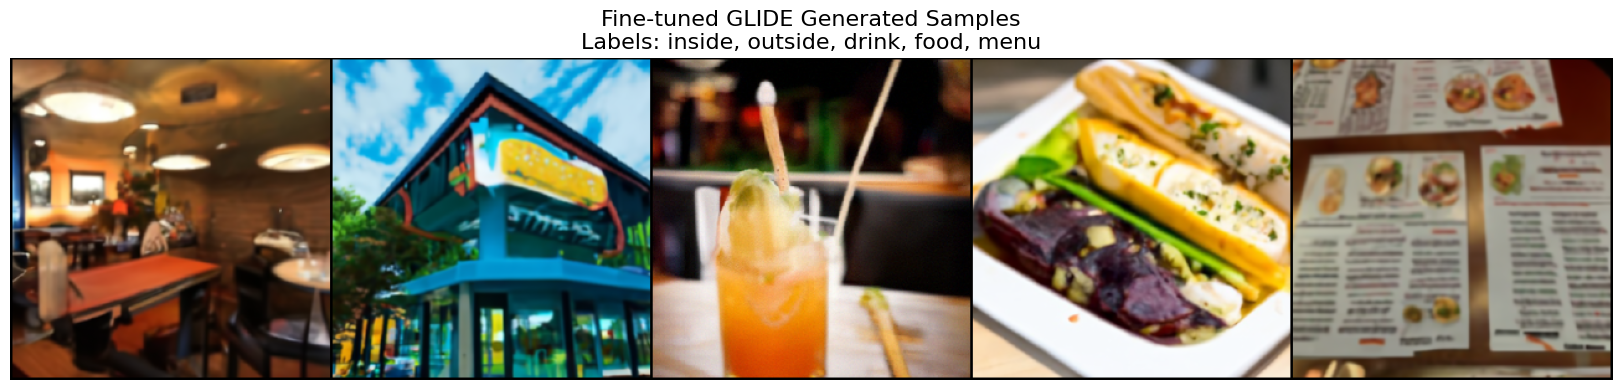

In [23]:
# Generate final results
grid_img, IS, FID, labels_generated, captions = generate_final_samples(
    model, diffusion, model_up, diffusion_up, device, TARGET_LABELS
)

In [24]:
# Display final results
print("\n" + "="*60)
print("GLIDE TEXT-TO-IMAGE FINE-TUNING RESULTS")
print("="*60)
print(f"Model: Fine-tuned GLIDE on Yelp Dataset")
print(f"Labels generated: {', '.join(labels_generated) if labels_generated else 'None'}")
print(f"Training epochs: {NUM_EPOCHS}")
print(f"Training samples: {len(df_train)}")
print(f"Final Inception Score: {IS:.4f}")
print(f"Final FID Score: {FID:.4f}")
print("="*60)


GLIDE TEXT-TO-IMAGE FINE-TUNING RESULTS
Model: Fine-tuned GLIDE on Yelp Dataset
Labels generated: inside, outside, drink, food, menu
Training epochs: 10
Training samples: 1000
Final Inception Score: 3.3577
Final FID Score: 1115.8836


In [26]:
# Save the final image grid
if grid_img is not None:
    # Create the results directory if it doesn't exist
    results_dir = "results"
    if not os.path.exists(results_dir):
        os.makedirs(results_dir)

    plt.figure(figsize=(20, 4))
    plt.imshow(grid_img.permute(1, 2, 0).numpy())
    plt.axis('off')
    plt.title(f"Fine-tuned GLIDE Generated Samples", fontsize=16)
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, "glide_generated_samples.png"), dpi=300, bbox_inches='tight')
    plt.close()

In [27]:
# Save detailed results
with open("results/glide_results.txt", "w") as f:
    f.write("GLIDE TEXT-TO-IMAGE DIFFUSION MODEL RESULTS\n")
    f.write("="*50 + "\n")
    f.write(f"Model: Fine-tuned GLIDE on Yelp Dataset\n")
    f.write(f"Training Configuration:\n")
    f.write(f"  - Epochs: {NUM_EPOCHS}\n")
    f.write(f"  - Batch Size: {BATCH_SIZE}\n")
    f.write(f"  - Learning Rate: {LEARNING_RATE}\n")
    f.write(f"  - Training Samples: {len(df_train)}\n")
    f.write(f"\nGenerated Labels: {', '.join(labels_generated) if labels_generated else 'None'}\n")
    f.write(f"Captions Used:\n")
    for label, caption in zip(labels_generated, captions):
        f.write(f"  - {label}: {caption}\n")
    f.write(f"\nEvaluation Metrics:\n")
    f.write(f"  - Inception Score: {IS:.4f}\n")
    f.write(f"  - FID Score: {FID:.4f}\n")

In [29]:
# Save the final trained model to Google Drive
from google.colab import drive
import os

# Mount Google Drive (if not already mounted)
# drive.mount('/content/drive') # This should be run in a separate cell

# Define the path in Google Drive
drive_path = "/content/drive/MyDrive/glide_models" # You can change "glide_models" to your desired folder name

# Create the directory in Google Drive if it doesn't exist
os.makedirs(drive_path, exist_ok=True)

# Define the full path for the model file
final_model_filename = "glide_yelp_final_model.pt"
final_model_path_in_drive = os.path.join(drive_path, final_model_filename)

# Save the model state dictionary
torch.save(model.state_dict(), final_model_path_in_drive)
print(f"Final trained model saved to: {final_model_path_in_drive}")

Final trained model saved to: /content/drive/MyDrive/glide_models/glide_yelp_final_model.pt


**LLM Used:** Gemini (Google Colab)

**1st Prompt:** I want to fine-tune a GLIDE text-to-image model using this data. How can I prepare this dataset to be used with a GLIDE model for fine-tuning, ensuring the images are correctly linked to their captions and the data is balanced by label?

**2nd Prompt:** After fine-tuning the GLIDE model with my dataset, I want to save the final trained model so I can use it later or continue fine-tuning. Provide the Python code to save the trained PyTorch model's state dictionary.